# Exploratory Data Analysis (EDA) on Retail Sales Dataset

## Oasis Infobyte Internship

### Name: Rachaita Sarkar

### Track: Data Analytics

### Task: EDA on Retail Sales Data

---

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to uncover sales trends, customer behavior, product performance, and business insights using Python.

# Importing required libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## Loading the Dataset

In [2]:
# Loading the dataset

df = pd.read_csv("retail_sales_dataset.csv")

# Display first five records
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Dataset Inspection

In [3]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns)

# Dataset Information
print("\nDataset Information:")
df.info()

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

# Missing Values
print("\nMissing Values:")
display(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB

Statistical Summary:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000



Missing Values:


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Duplicate Rows:
0


In [4]:
# Mean
print("Mean")
display(df.mean(numeric_only=True))

# Median
print("\nMedian")
display(df.median(numeric_only=True))

# Mode
print("\nMode")
display(df.mode().head(1))

# Standard Deviation
print("\nStandard Deviation")
display(df.std(numeric_only=True))

Mean


Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


Median


Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


Mode


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-05-16,CUST001,Female,43.0,Clothing,4.0,50.0,50.0



Standard Deviation


Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

### Observation

The dataset was successfully inspected for its dimensions, structure, descriptive statistics, missing values, and duplicate records. The calculated mean, median, mode, and standard deviation provide a better understanding of the distribution of the numerical variables before further analysis.

## Monthly Sales Trend Analysis

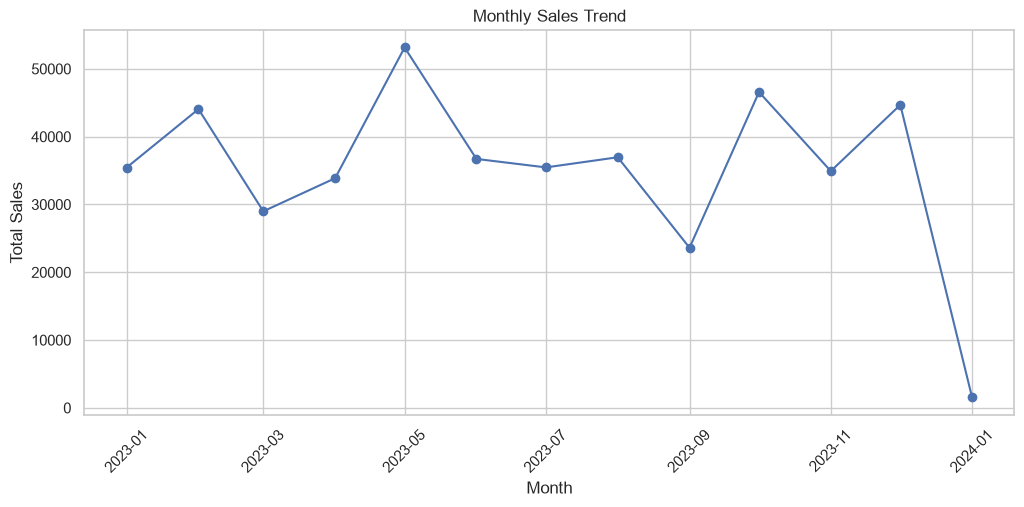

In [5]:
# Convert the Date column into datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Calculate monthly sales
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

# Convert PeriodIndex to Timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot Monthly Sales Trend
plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

The monthly sales trend shows how sales change over time. It helps identify high-performing months and periods of lower sales, which can support better inventory planning and marketing strategies.

## Quarterly Sales Trend Analysis

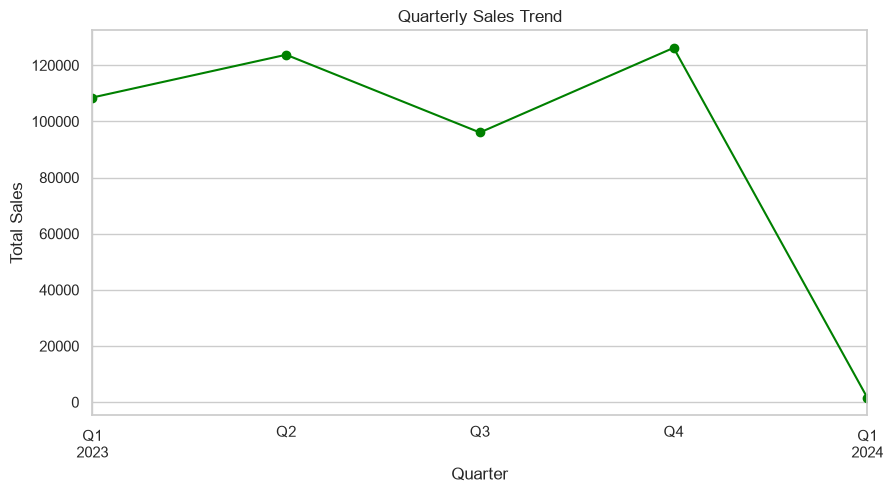

In [6]:
quarterly_sales = df.groupby(df["Date"].dt.to_period("Q"))["Total Amount"].sum()

plt.figure(figsize=(10,5))

quarterly_sales.plot(marker="o", color="green")

plt.title("Quarterly Sales Trend")

plt.xlabel("Quarter")

plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

### Observation

Quarterly sales analysis helps identify seasonal trends, peak sales periods, and business growth patterns. These insights can assist in inventory management and marketing planning.

## Customer Demographics Analysis

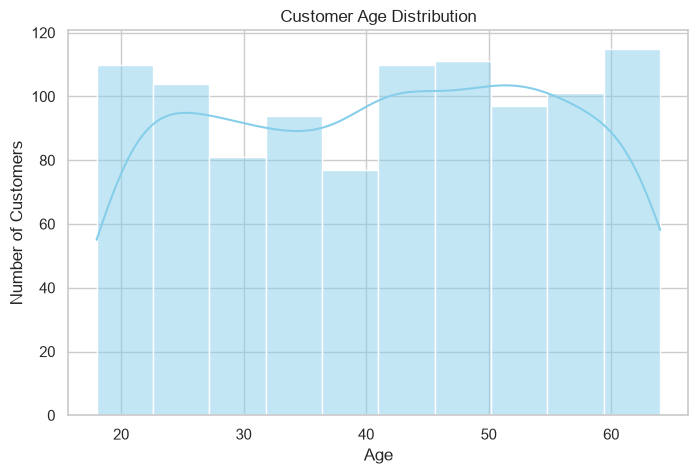

In [7]:
# Customer Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=10, kde=True, color="skyblue")

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## Gender Distribution

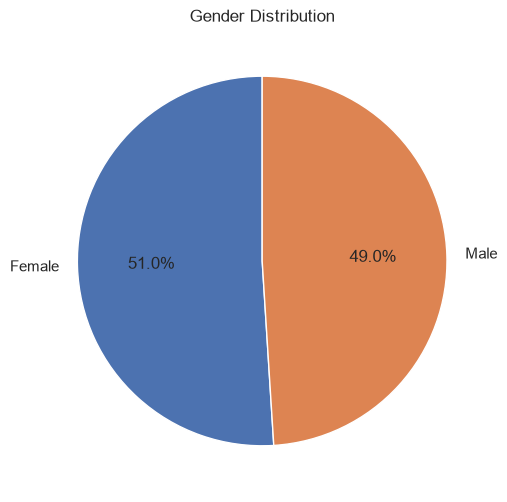

In [8]:
# Gender Distribution

plt.figure(figsize=(6,6))

df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

### Observation

The customer demographic analysis shows the distribution of customers based on age and gender. These insights help businesses understand their target audience and design more effective marketing strategies.

## Product Category Analysis

### Top Product Categories by Quantity Sold

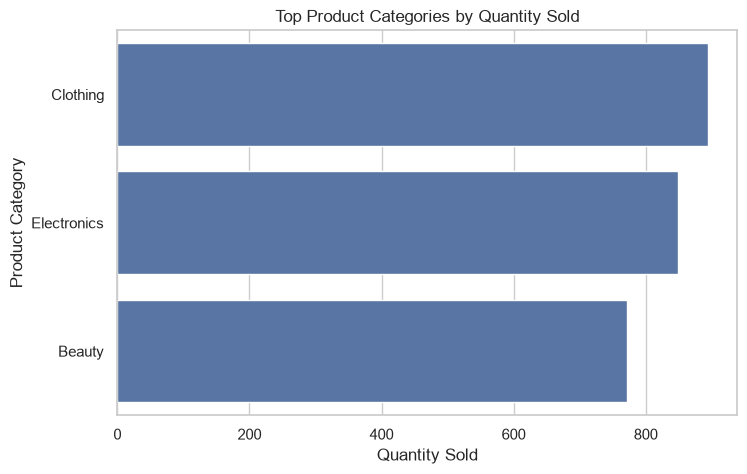

In [9]:
top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Product Categories by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.show()

### Revenue by Product Category

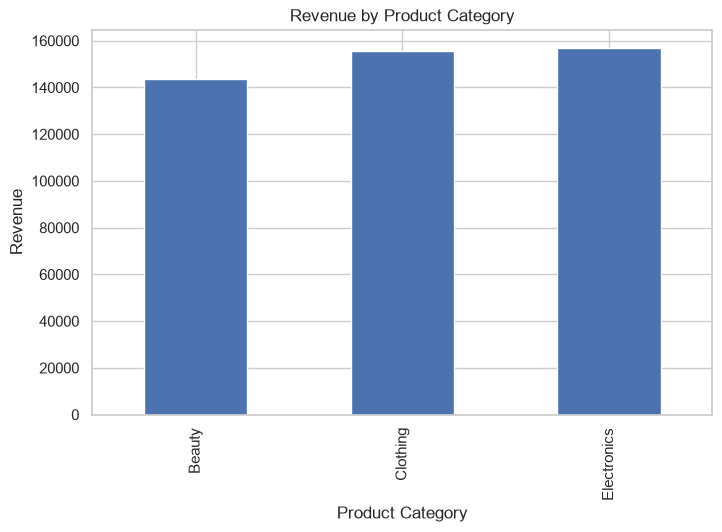

In [10]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

### Observation

The product category analysis identifies the highest-performing categories in terms of sales volume and revenue generation. These insights support inventory optimization and product planning.

## Correlation Analysis

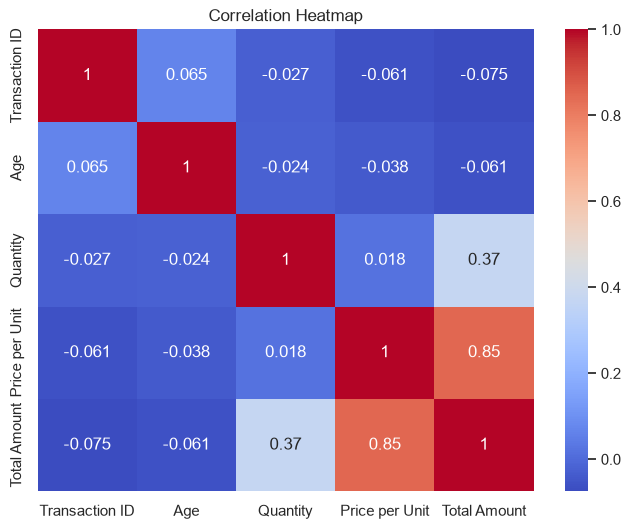

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation matrix illustrates relationships between numerical variables. Strong positive or negative correlations can support data-driven business decisions.

## Revenue Analysis by Gender

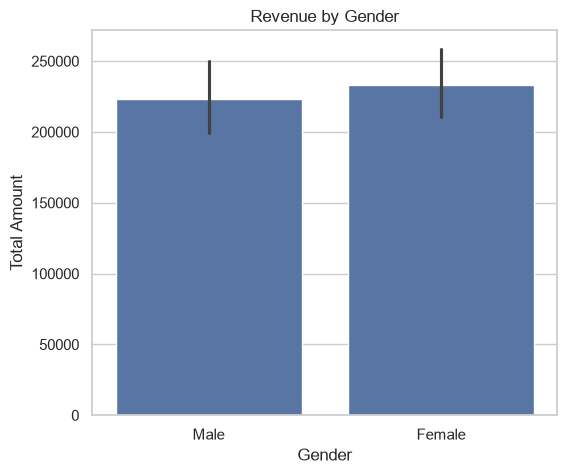

In [12]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="Gender",
    y="Total Amount",
    estimator=sum
)

plt.title("Revenue by Gender")

plt.show()

### Observation

The visualization compares revenue generated by different customer groups and helps identify the highest-contributing customer segment.

# Conclusion

The exploratory analysis revealed significant insights into customer behavior, product performance, and sales trends. The findings can assist businesses in making informed strategic decisions.

## Business Recommendations

1. Increase inventory for high-performing product categories to prevent stock shortages.
2. Develop targeted marketing campaigns based on customer demographics.
3. Utilize seasonal sales trends for better inventory and promotional planning.
4. Focus on customer retention strategies to improve repeat purchases.
5. Continue monitoring sales performance using data dashboards for real-time business insights.